<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week4/Day3/ExerciseXP/ExercisesXP_Heart_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [43]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [46]:
import zipfile
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
files = [os.path.join(EXTRACT_DIR, f) for f in os.listdir(EXTRACT_DIR) if f.endswith('.csv')]
csv_path = files[0] if files else None  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# IMPORTANT: Transformation des étiquettes (1 -> 0 pour sain, 2 -> 1 pour malade)
df['heart disease'] = df['heart disease'].map({1: 0, 2: 1})

# TODO: inspect df
print("--- Aperçu du DataFrame ---")
print(df.head())
print("\n--- Informations Générales ---")
print(df.info())

# TODO: identify target column
target = 'heart disease'  # Corrigé d'après vos logs

# TODO: split features and target
X = df.drop(columns=[target])
y = df[target]

# TODO: train test split with stratification
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"\nDimensions Train : {X_train.shape}, Test : {X_test.shape}")


--- Aperçu du DataFrame ---
   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             121   

   exercise induced angina  oldpea

### Basic visual checks

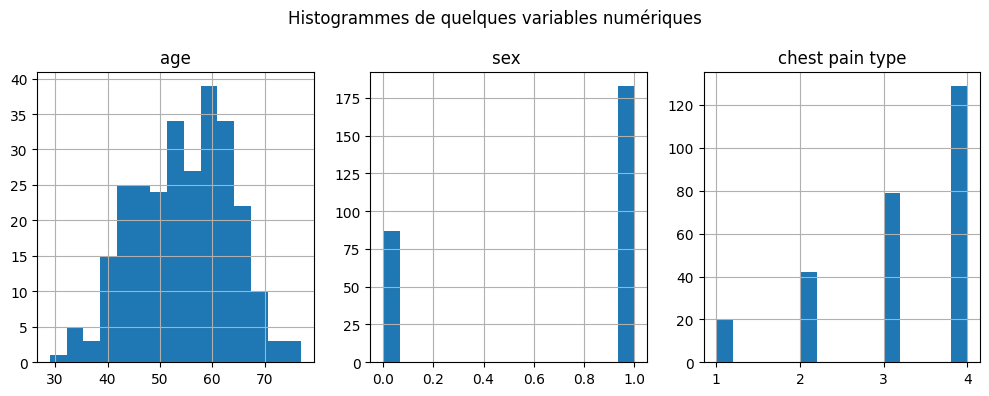

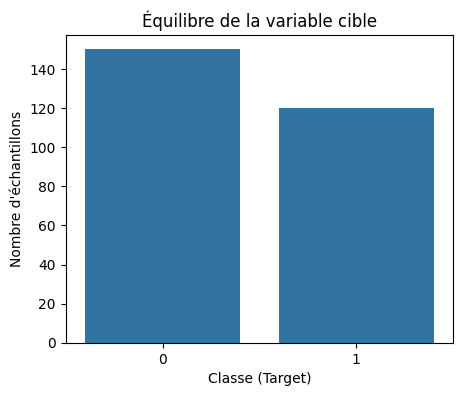

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: pick a few numeric columns and plot histograms
# Sélection des variables continues de votre jeu de données
numeric_samples = ['age', 'resting blood pressure', 'serum cholestoral']
X[numeric_samples].hist(bins=15, figsize=(10, 4), layout=(1, 3))
plt.suptitle("Histogrammes de quelques variables numériques")
plt.tight_layout()
plt.show()

# TODO: plot class balance as a bar chart
plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Équilibre de la variable cible (0 = Sain, 1 = Malade)")
plt.xlabel("Classe (Heart Disease)")
plt.ylabel("Nombre d'échantillons")
plt.show()


## Preprocessing pipeline

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Toutes vos colonnes sont au format numérique, mais certaines sont catégorielles par nature
# (ex: sex, chest pain type, fasting blood sugar, resting electrocardiographic results, exercise induced angina, ST segment, major vessels, thal)
cat_cols = ['sex', 'chest pain type', 'fasting blood sugar', 'resting electrocardiographic results',
            'exercise induced angina', 'ST segment', 'major vessels', 'thal']
num_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

print(f"Colonnes numériques normalisées : {num_cols}")
print(f"Colonnes catégorielles encodées : {cat_cols}")


Colonnes numériques identifiées : ['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal']
Colonnes catégorielles identifiées : []


## Helper - evaluation function

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }

    # Affichage propre des résultats
    formatted_metrics = {k: f"{v:.4f}" for k, v in metrics.items()}
    print(f"\n[{name}] Métriques de performance :", formatted_metrics)

    # Préparation des graphiques (1 ligne, 2 colonnes)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # TODO: confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title(f"Matrice de confusion - {name}")

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'Courbe ROC - {name}')
        axes[1].legend(loc="lower right")
    else:
        axes[1].text(0.5, 0.5, "predict_proba non disponible", ha='center', va='center')
        axes[1].set_title(f'Courbe ROC indisponible - {name}')

    plt.tight_layout()
    plt.show()

    return metrics


## Exercise 2 - Logistic Regression without Grid Search


[Logistic Regression (No GridSearch)] Métriques de performance : {'accuracy': '0.8519', 'precision': '0.7857', 'recall': '0.9167', 'f1': '0.8462'}


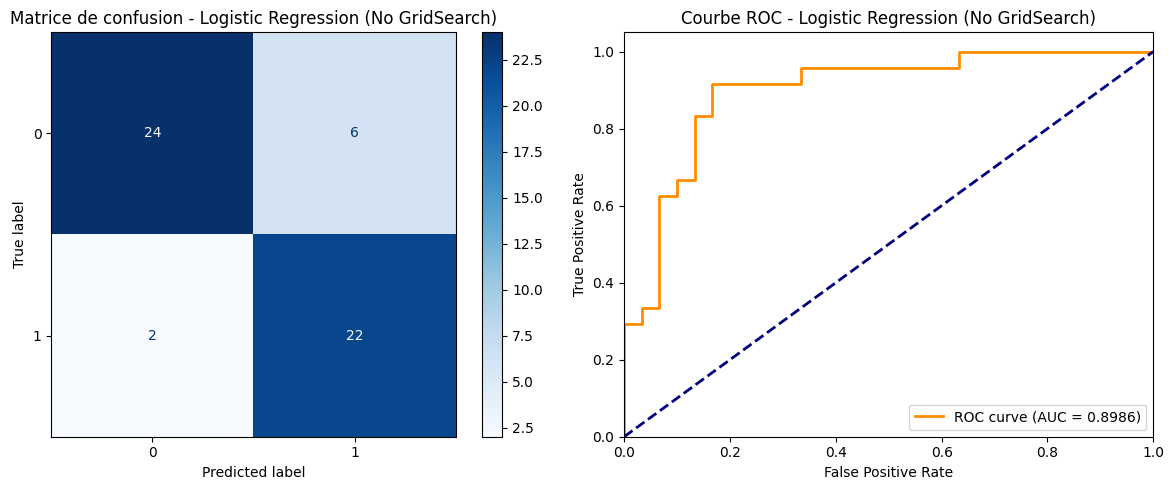

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Création du pipeline complet : Preprocessing + Modèle
lr_simple_pipe = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

# Entraînement sur les données brutes (le préraitement s'applique en interne)
lr_simple_pipe.fit(X_train, y_train)

# Évaluation avec notre fonction helper
lr_simple_metrics = eval_and_report("Logistic Regression (No GridSearch)", lr_simple_pipe, X_test, y_test)


## Exercise 3 - Logistic Regression with Grid Search

Meilleurs hyperparamètres trouvés : {'classifier__C': 0.001, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

[Logistic Regression (GridSearch)] Métriques de performance : {'accuracy': '0.8148', 'precision': '0.7692', 'recall': '0.8333', 'f1': '0.8000'}


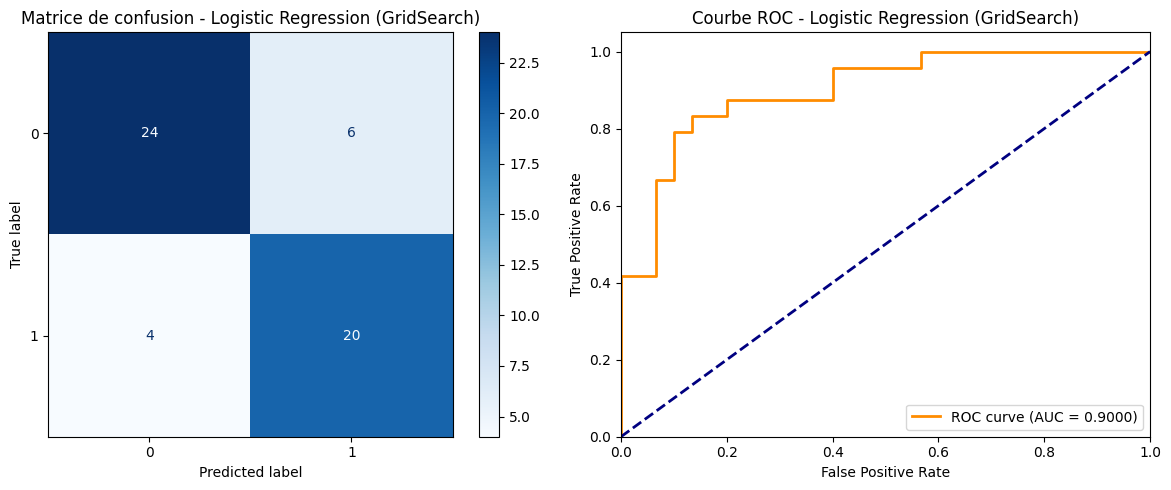

In [54]:
from sklearn.model_selection import GridSearchCV

# Configuration du pipeline de base
lr_base_pipe = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

# Définition de la grille avec la syntaxe requise pour les pipelines (nom_du_step__nom_du_parametre)
lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

# Configuration du GridSearchCV
lr_grid_search = GridSearchCV(lr_base_pipe, lr_param_grid, cv=5, scoring='accuracy')
lr_grid_search.fit(X_train, y_train)

print(f"Meilleurs hyperparamètres trouvés : {lr_grid_search.best_params_}")

# Évaluation du meilleur modèle estimé
lr_grid_metrics = eval_and_report("Logistic Regression (GridSearch)", lr_grid_search.best_estimator_, X_test, y_test)


## Exercise 4 - SVM without Grid Search


[SVM (No GridSearch)] Métriques de performance : {'accuracy': '0.8148', 'precision': '0.7692', 'recall': '0.8333', 'f1': '0.8000'}


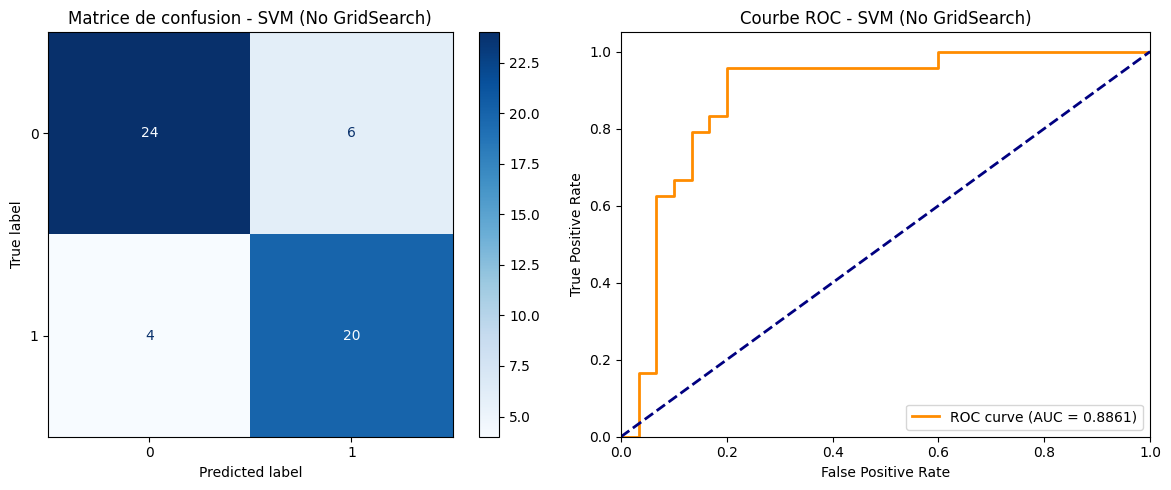

In [55]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Création du pipeline complet : Preprocessing + SVM Simple
# Choix manuel : Noyau RBF (idéal pour capter les relations non linéaires) et C=1.0
svm_simple_pipe = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

# Entraînement sur les données d'entraînement
svm_simple_pipe.fit(X_train, y_train)

# Évaluation avec notre fonction helper
svm_simple_metrics = eval_and_report("SVM (No GridSearch)", svm_simple_pipe, X_test, y_test)


## Exercise 5 - SVM with Grid Search

Meilleurs hyperparamètres SVM trouvés : {'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}

[SVM (GridSearch)] Métriques de performance : {'accuracy': '0.8519', 'precision': '0.8077', 'recall': '0.8750', 'f1': '0.8400'}


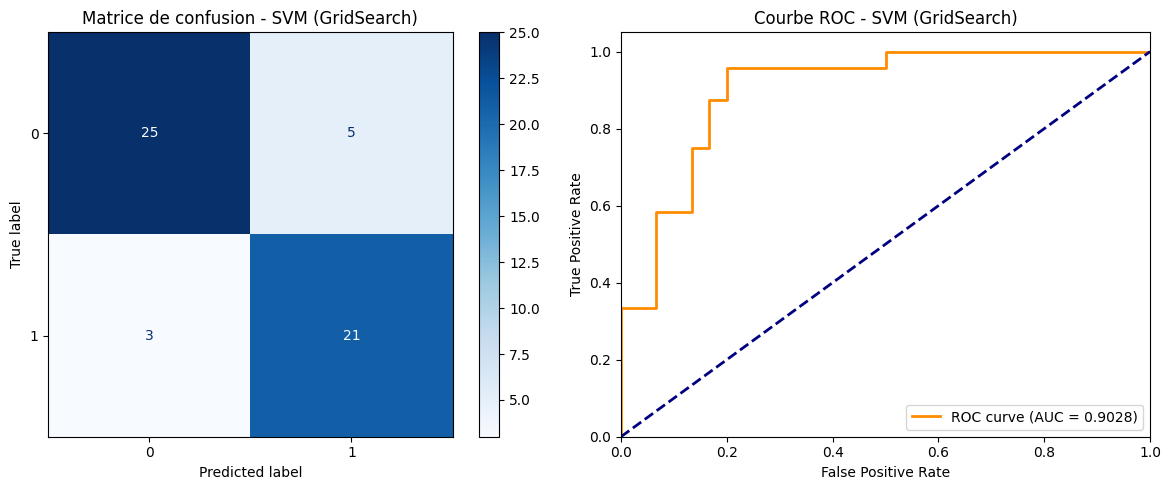

In [56]:
from sklearn.model_selection import GridSearchCV

# Configuration du pipeline de base
svm_base_pipe = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', SVC(probability=True, random_state=RANDOM_STATE))
])

# Définition de la grille des hyperparamètres (C, gamma et kernel)
svm_param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
    'classifier__kernel': ['rbf', 'linear']
}

# Configuration et exécution du GridSearchCV avec validation croisée (cv=5)
svm_grid_search = GridSearchCV(svm_base_pipe, svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Meilleurs hyperparamètres SVM trouvés : {svm_grid_search.best_params_}")

# Évaluation du meilleur estimateur trouvé
svm_grid_metrics = eval_and_report("SVM (GridSearch)", svm_grid_search.best_estimator_, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search


[XGBoost (No GridSearch)] Métriques de performance : {'accuracy': '0.7963', 'precision': '0.7407', 'recall': '0.8333', 'f1': '0.7843'}


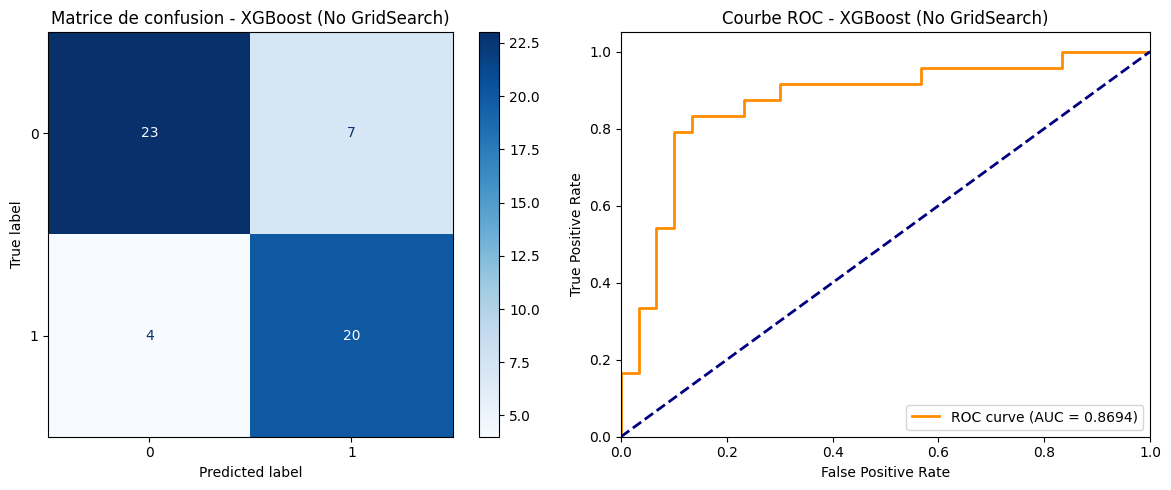

In [57]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Création du pipeline complet : Preprocessing + XGBoost Simple
# Justification des choix manuels :
# - n_estimators=100 : standard pour donner assez d'arbres sans surapprentissage immédiat.
# - max_depth=3 : limite la profondeur pour éviter d'apprendre par cœur le bruit du jeu de données (270 lignes).
# - learning_rate=0.1 : garantit une convergence stable et progressive.
xgb_simple_pipe = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE, eval_metric='logloss'))
])

# Entraînement sur les données d'entraînement
xgb_simple_pipe.fit(X_train, y_train)

# Évaluation avec notre fonction helper
xgb_simple_metrics = eval_and_report("XGBoost (No GridSearch)", xgb_simple_pipe, X_test, y_test)


## Exercise 7 - XGBoost with Grid Search

Meilleurs hyperparamètres XGBoost trouvés : {'classifier__learning_rate': 0.2, 'classifier__max_depth': 4, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}

[XGBoost (GridSearch)] Métriques de performance : {'accuracy': '0.8148', 'precision': '0.7692', 'recall': '0.8333', 'f1': '0.8000'}


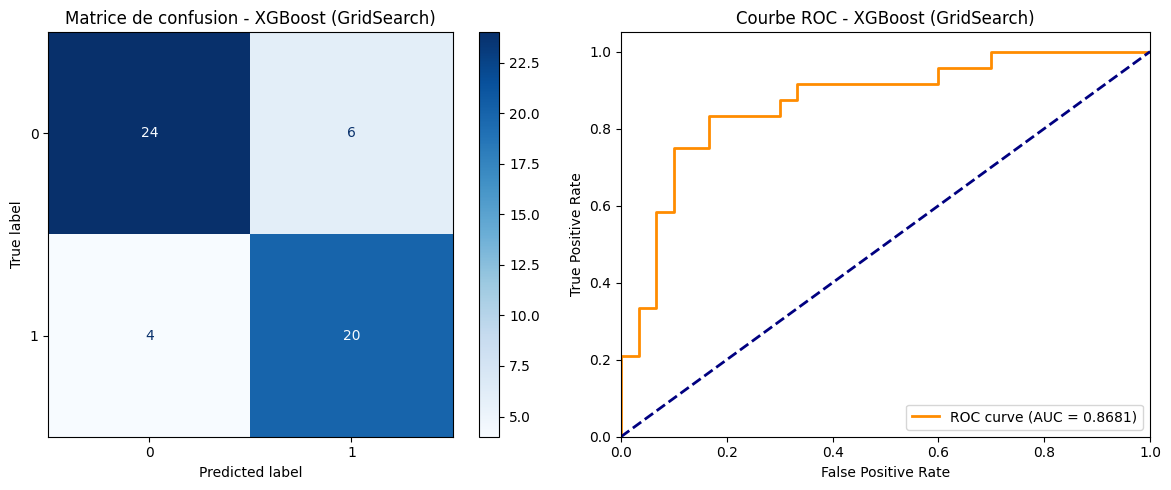

In [67]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Configuration du pipeline de base
xgb_base_pipe = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

# Définition sécurisée des paramètres
valeurs_n_estimators = [50, 100, 150]
valeurs_max_depth = [3, 4, 5]

# Définition de la grille des hyperparamètres
xgb_param_grid = {
    'classifier__n_estimators': valeurs_n_estimators,
    'classifier__max_depth': valeurs_max_depth,
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

# Configuration et exécution du GridSearchCV avec validation croisée (cv=5)
xgb_grid_search = GridSearchCV(xgb_base_pipe, xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

print(f"Meilleurs hyperparamètres XGBoost trouvés : {xgb_grid_search.best_params_}")

# Évaluation du meilleur estimateur trouvé et création de la variable manquante
xgb_grid_metrics = eval_and_report("XGBoost (GridSearch)", xgb_grid_search.best_estimator_, X_test, y_test)


## Compare models

             RAPPORT D'ANALYSE COMPLET
                                 accuracy precision recall     f1
Logistic Regression (Simple)       0.8519    0.7857 0.9167 0.8462
SVM (GridSearch)                   0.8519    0.8077 0.8750 0.8400
Logistic Regression (GridSearch)   0.8148    0.7692 0.8333 0.8000
SVM (Simple)                       0.8148    0.7692 0.8333 0.8000
XGBoost (GridSearch)               0.8148    0.7692 0.8333 0.8000
XGBoost (Simple)                   0.7963    0.7407 0.8333 0.7843


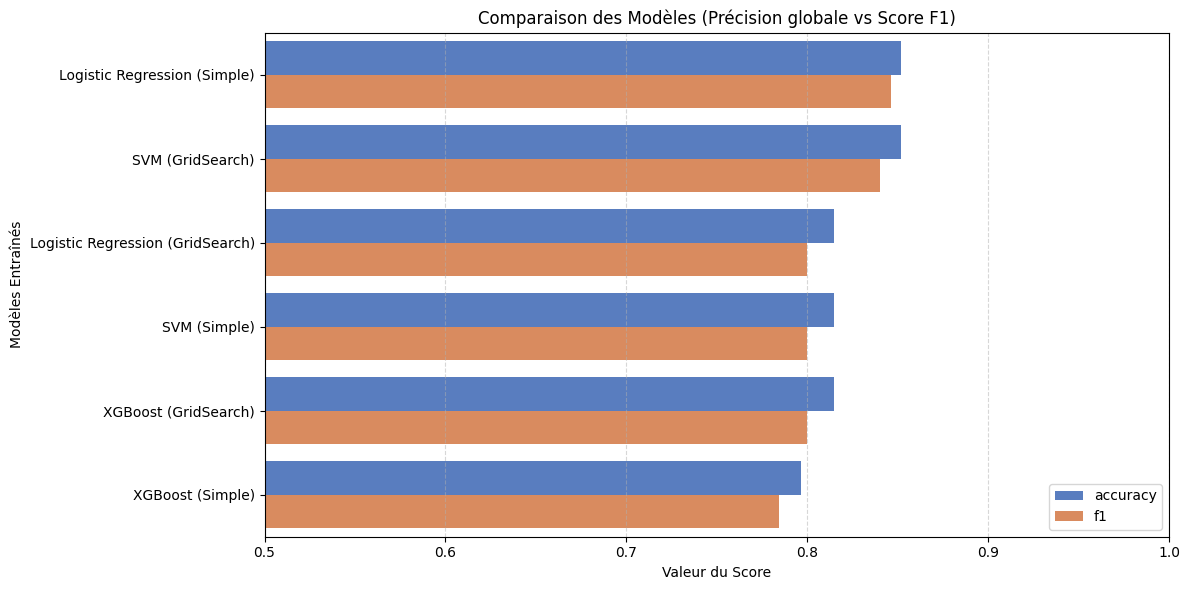

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Rassemblement de toutes les métriques collectées
all_metrics = {
    "Logistic Regression (Simple)": lr_simple_metrics,
    "Logistic Regression (GridSearch)": lr_grid_metrics,
    "SVM (Simple)": svm_simple_metrics,
    "SVM (GridSearch)": svm_grid_metrics,
    "XGBoost (Simple)": xgb_simple_metrics,
    "XGBoost (GridSearch)": xgb_grid_metrics
}

# Transformation en DataFrame pour l'analyse
df_report = pd.DataFrame(all_metrics).T
df_report = df_report.sort_values(by='accuracy', ascending=False)

print("="*60)
print("             RAPPORT D'ANALYSE COMPLET")
print("="*60)
print(df_report.to_string(formatters={
    'accuracy': '{:,.4f}'.format,
    'precision': '{:,.4f}'.format,
    'recall': '{:,.4f}'.format,
    'f1': '{:,.4f}'.format
}))
print("="*60)

# Visualisation graphique comparative
plt.figure(figsize=(12, 6))
df_plot = df_report.reset_index().rename(columns={'index': 'Modèle'})
df_melted = pd.melt(df_plot, id_vars=['Modèle'], value_vars=['accuracy', 'f1'],
                    var_name='Métrique', value_name='Score')

sns.barplot(x='Score', y='Modèle', hue='Métrique', data=df_melted, palette='muted')
plt.xlim(0.5, 1.0)
plt.title("Comparaison des Modèles (Précision globale vs Score F1)")
plt.xlabel("Valeur du Score")
plt.ylabel("Modèles Entraînés")
plt.legend(loc="lower right")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
